<a href="https://colab.research.google.com/github/Adit2006-bit/portfolio/blob/main/LiveProject_Salary_Decoder_Adit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!
Shape of Dataset: (1015, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Employee_ID     1015 non-null   object
 1   Role            1015 non-null   object
 2   years_exp       1015 non-null   int64 
 3   Current_CTC     1015 non-null   object
 4   Previous_CTC    815 non-null    object
 5   Company         1015 non-null   object
 6   company_TYPE    1015 non-null   object
 7   Skills          988 non-null    object
 8   Location        995 non-null    object
 9   Education_Tier  1015 non-null   object
 10  Joining_Year    1015 non-null   int64 
 11  Work_Mode       1015 non-null   object
dtypes: int64(2), object(10)
memory usage: 95.3+ KB
Duplicate Rows: 15
Index(['employee_id', 'role', 'years_exp', 'current_ctc', 'previous_ctc',
       'company', 'company_type', 'skills', 'location', 'education_tier',


/tmp/ipykernel_12540/1018767653.py:222: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  backend_df.groupby("exp_band")["current_ctc_lpa"]
/tmp/ipykernel_12540/1018767653.py:292: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["group_size"] = df.groupby(group_cols)["current_ctc_lpa"].transform("size")
/tmp/ipykernel_12540/1018767653.py:294: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["group_median"] = df.groupby(group

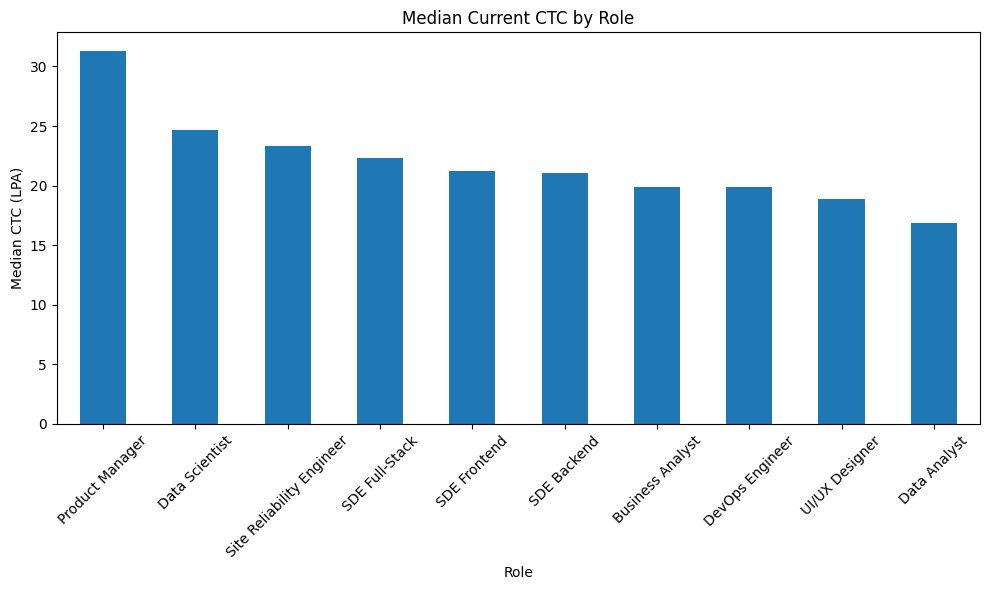

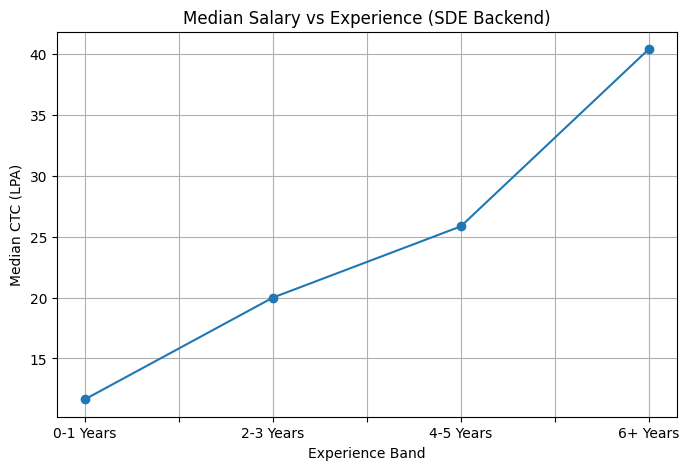

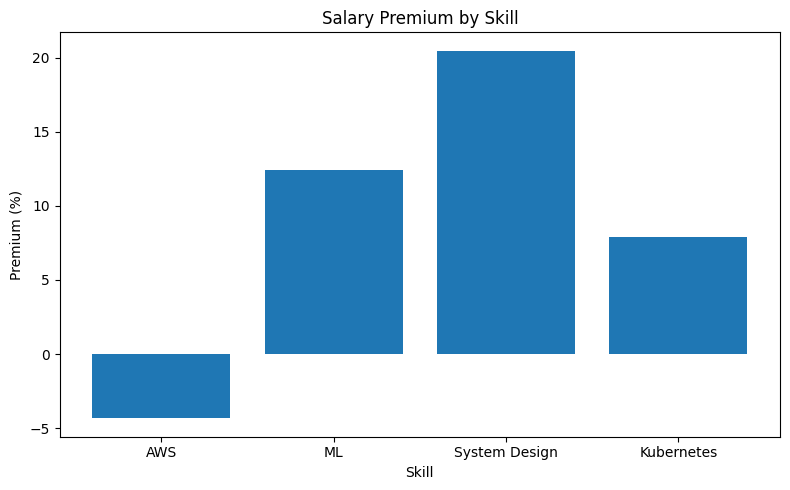

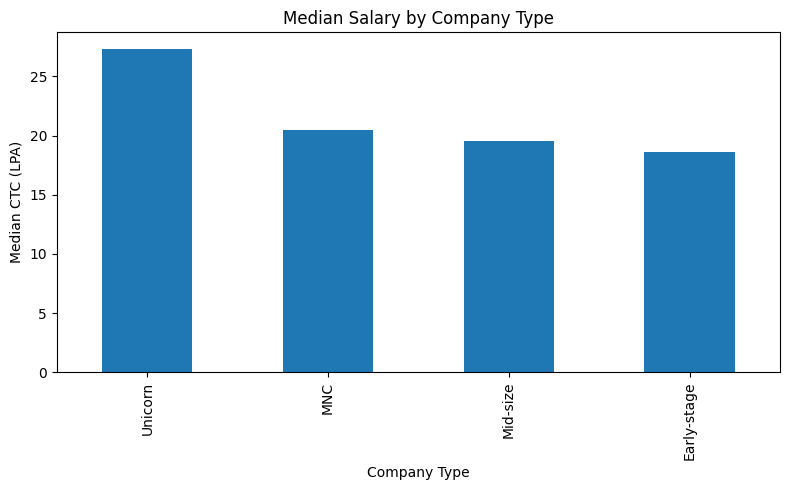

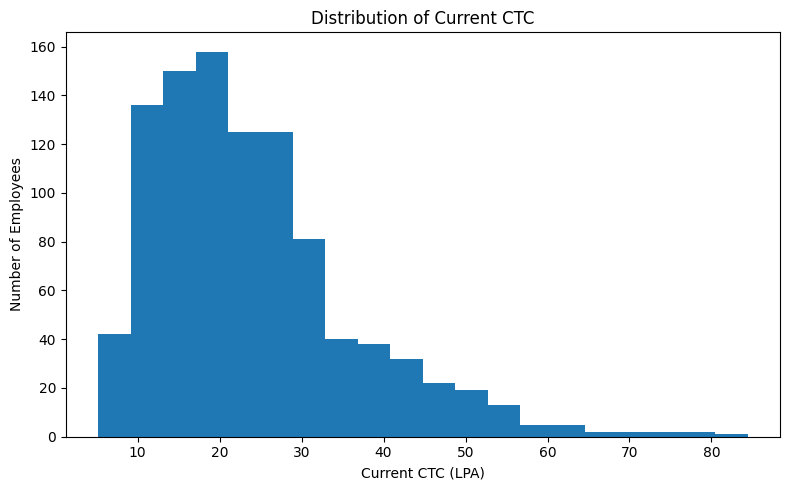

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/bangalore_tech_salaries.csv")
print("Dataset loaded successfully!")
df.head()
#Task 1
# Find the number of rows and columns
print("Shape of Dataset:", df.shape)
# Display information about columns and data types
df.info()
# Display data types of every column
df.dtypes
# Count missing values in every column
df.isnull().sum()
# Count duplicate records
print("Duplicate Rows:", df.duplicated().sum())
# Generate summary statistics for all columns
df.describe(include="all")
# Rename all column names to snake_case
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)
print(df.columns)
# Inspect all unique role names before creating the mapping
sorted(df["role"].unique())
## Standardizing Role Names
#The `role` column contains multiple variations of the same job title. To ensure accurate analysis, all similar role names are mapped to a single standardized role.
# Strategy: Standardize different role variants into a single canonical role.

role_mapping = {

    # ---------------- SDE Backend ----------------
    "Backend Dev": "SDE Backend",
    "Backend Developer": "SDE Backend",
    "Backend Engineer": "SDE Backend",
    "BE": "SDE Backend",
    "SDE Backend": "SDE Backend",
    "SDE-Backend": "SDE Backend",
    # ---------------- SDE Frontend ----------------
    "Frontend Dev": "SDE Frontend",
    "Frontend Developer": "SDE Frontend",
    "Frontend Engineer": "SDE Frontend",
    "FE": "SDE Frontend",
    "SDE Frontend": "SDE Frontend",
    "SDE-Frontend": "SDE Frontend",
    # ---------------- Full Stack ----------------
    "FullStack": "SDE Full-Stack",
    "Fullstack Dev": "SDE Full-Stack",
    "Full Stack Engineer": "SDE Full-Stack",
    "SDE FS": "SDE Full-Stack",
    "SDE Full-Stack": "SDE Full-Stack",
    # ---------------- Data Scientist ----------------
    "DS": "Data Scientist",
    "Data Scientist": "Data Scientist",
    "Data Science Engineer": "Data Scientist",
    "ML Engineer": "Data Scientist",
    # ---------------- Data Analyst ----------------
    "DA": "Data Analyst",
    "Data Analyst": "Data Analyst",
    "BI Analyst": "Data Analyst",
    "Analytics Engineer": "Data Analyst",
    # ---------------- Business Analyst ----------------
    "BA": "Business Analyst",
    "Business Analyst": "Business Analyst",
    "Business Systems Analyst": "Business Analyst",
    # ---------------- DevOps ----------------
    "DevOps": "DevOps Engineer",
    "DevOps Engineer": "DevOps Engineer",
    "Infra Engineer": "DevOps Engineer",
    "SRE": "Site Reliability Engineer",
    "Site Reliability Engineer": "Site Reliability Engineer",
    # ---------------- Product ----------------
    "PM": "Product Manager",
    "Sr PM": "Product Manager",
    "Product Lead": "Product Manager",
    "Product Manager": "Product Manager",
    # ---------------- Design ----------------
    "Designer": "UI/UX Designer",
    "UI Designer": "UI/UX Designer",
    "UX Designer": "UI/UX Designer",
    "UI/UX": "UI/UX Designer",
    "Product Designer": "UI/UX Designer"
}
# Create a cleaned role column
df["role_clean"] = df["role"].replace(role_mapping)
# Check standardized role counts
print(df["role_clean"].value_counts())
# Check all unique values in the company_type column
sorted(df["company_type"].unique())
## Standardizing Company Type
#The `company_type` column contains the same company categories written in different cases (uppercase, lowercase, and mixed case). These values are standardized into four consistent categories to ensure accurate grouping and analysis.
# Strategy: Convert different case variations into four standard company types.
company_type_mapping = {
    # Unicorn
    "UNICORN": "Unicorn",
    "Unicorn": "Unicorn",
    "unicorn": "Unicorn",
    # MNC
    "MNC": "MNC",
    "mnc": "MNC",
    # Mid-size
    "MID-SIZE": "Mid-size",
    "Mid-size": "Mid-size",
    "mid-size": "Mid-size",
    # Early-stage
    "EARLY-STAGE": "Early-stage",
    "Early-stage": "Early-stage",
    "early-stage": "Early-stage"
}
# Create a cleaned company type column
df["company_type_clean"] = df["company_type"].replace(company_type_mapping)
# Verify the standardized company types
print(df["company_type_clean"].value_counts())
# Display all unique education tier values
sorted(df["education_tier"].unique())
## Standardizing Education Tier The `education_tier` column contains multiple representations of the same education level, such as "Tier 1", "T1", "1", and "Tier-1". These values are standardized into three consistent categories for accurate analysis.
# Strategy: Convert different representations into three standard education tiers.
education_tier_mapping = {
    # Tier 1
    "Tier 1": "Tier 1",
    "Tier-1": "Tier 1",
    "T1": "Tier 1",
    "1": "Tier 1",
    # Tier 2
    "Tier 2": "Tier 2",
    "Tier-2": "Tier 2",
    "T2": "Tier 2",
    "2": "Tier 2",
    # Tier 3
    "Tier 3": "Tier 3",
    "Tier-3": "Tier 3",
    "T3": "Tier 3",
    "3": "Tier 3"
}
# Create cleaned education tier column
df["education_tier_clean"] = df["education_tier"].replace(education_tier_mapping)
print(df["education_tier_clean"].value_counts())
## Converting Salary Columns to Numeric (LPA)
#The salary columns contain multiple formats such as "15.5 LPA", "₹15.5 LPA", "15.5", and "15,50,000". A custom function is used to convert all formats into a consistent numeric LPA value for analysis.
# Strategy:
# 1. Handle missing values.
# 2. Convert "₹15.5 LPA" and "15.5 LPA" to 15.5.
# 3. Convert "15,50,000" to 15.5 LPA
# 4. Convert plain numeric strings to float.
import pandas as pd
import numpy as np
def parse_ctc(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    # Remove rupee symbol
    value = value.replace("₹", "")
    # Handle LPA format
    if "LPA" in value.upper():
        value = value.upper().replace("LPA", "").strip()
        return float(value)
    # Handle Indian comma-separated salary
    if "," in value:
        salary = float(value.replace(",", ""))
        return salary / 100000
    # Plain numeric value
    return float(value)
    # Convert current and previous CTC into numeric LPA
df["current_ctc_lpa"] = df["current_ctc"].apply(parse_ctc)
df["previous_ctc_lpa"] = df["previous_ctc"].apply(parse_ctc)
df[["current_ctc", "current_ctc_lpa"]].head(15)
df[["current_ctc_lpa", "previous_ctc_lpa"]].dtypes
# Verify that all salary formats have been converted correctly
df[["current_ctc", "current_ctc_lpa"]].sample(10, random_state=42)
df[["previous_ctc", "previous_ctc_lpa"]].sample(10, random_state=42)
## Handling Missing Values
#Missing values are handled based on the meaning of each column. Previous salary values are left as missing because they represent freshers or career changers. Missing skills and locations are filled with "Unknown" to retain those records for analysis.
# Keep Previous_CTC as NaN (do NOT replace with 0)
# Fill missing skills and location values
df["skills"] = df["skills"].fillna("Unknown")
df["location"] = df["location"].fillna("Unknown")
df[["previous_ctc_lpa", "skills", "location"]].isnull().sum()
## Removing Duplicate Records
#Duplicate rows are removed to ensure that every employee is represented only once in the dataset.
# Remove duplicate records
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())
# Display data types after cleaning
print("Data Types:")
print(df.dtypes)
print("\nRole Distribution:")
print(df["role_clean"].value_counts())
print("\nCompany Type Distribution:")
print(df["company_type_clean"].value_counts())
print("\nEducation Tier Distribution:")
print(df["education_tier_clean"].value_counts())
# Task 3.1 – CTC Distribution by Role
### Objective
#Calculate the median, mean, minimum, and maximum current CTC for each standardized role. The roles will be sorted by median CTC to identify the highest and lowest paying roles and to observe whether the mean differs significantly from the median, which may indicate the presence of salary outliers.
# Calculate salary statistics for each role
role_salary = (
    df.groupby("role_clean")["current_ctc_lpa"]
      .agg(["median", "mean", "min", "max"])
      .sort_values(by="median", ascending=False)
)
print(role_salary)
### Insight (Q3.1)
#The analysis shows that **Product Managers** have the highest median salary (**31.30 LPA**), making them the highest-paid role in the dataset. On the other hand, **Data Analysts** have the lowest median salary (**16.90 LPA**).
#For most roles, the mean salary is higher than the median salary. This indicates the presence of a few highly paid professionals that increase the average salary. For example, **SDE Frontend** has a maximum salary of **84.4 LPA**, while its median salary is only **21.2 LPA**, suggesting the presence of salary outliers. Therefore, the median provides a better representation of the typical salary than the mean.
# Task 3.2 – Experience Curve for SDE Backend
### Objective
#Analyse how the median salary changes with increasing experience for SDE Backend professionals by grouping them into four experience bands.
# Filter only SDE Backend professionals
backend_df = df[df["role_clean"] == "SDE Backend"].copy()
# Create experience bands
backend_df["exp_band"] = pd.cut(
    backend_df["years_exp"],
    bins=[-1, 1, 3, 5, 100],
    labels=["0-1 Years", "2-3 Years", "4-5 Years", "6+ Years"]
)
# Calculate median CTC by experience band
backend_salary = (
    backend_df.groupby("exp_band")["current_ctc_lpa"]
              .median()
)
print(backend_salary)
# Calculate percentage growth in median salary
growth = backend_salary.pct_change() * 100
growth = growth.round(2)
print(growth)
# Insight (Q3.2)
#The median salary of **SDE Backend** professionals increases steadily with experience.
# 0–1 Years: **11.65 LPA**
#2–3 Years: **20.00 LPA**
#4–5 Years: **25.85 LPA**
#6+ Years: **40.40 LPA**
#The largest salary jump occurs between **0–1 years and 2–3 years**, with a growth of approximately **71.67%**. Another significant increase is observed after **6 years of experience**, where the median salary reaches **40.40 LPA**. This indicates that experience plays a major role in salary progression for backend engineers.
# Task 3.3 – Skill Premium for SDEs
# Objective
#Compare the median salary of SDE professionals who possess a particular skill with those who do not, in order to determine the salary premium associated with each skill.
# Filter all SDE roles
sde_df = df[df["role_clean"].isin([
    "SDE Backend",
    "SDE Frontend",
    "SDE Full-Stack"
])]
skills = ["AWS", "ML", "System Design", "Kubernetes"]
results = []
for skill in skills:
    has_skill = sde_df[sde_df["skills"].str.contains(skill, case=False, na=False)]
    no_skill = sde_df[~sde_df["skills"].str.contains(skill, case=False, na=False)]
    with_skill = has_skill["current_ctc_lpa"].median()
    without_skill = no_skill["current_ctc_lpa"].median()
    premium = ((with_skill - without_skill) / without_skill) * 100
    results.append([skill, with_skill, without_skill, premium])
skill_premium = pd.DataFrame(
    results,
    columns=["Skill", "With Skill", "Without Skill", "Premium (%)"]
)
print(skill_premium)
### Insight (Q3.3)
#Among the selected technical skills, **System Design** offers the highest salary premium of approximately **20.48%**, followed by **Machine Learning (12.44%)** and **Kubernetes (7.91%)**.
#Interestingly, professionals with **AWS** listed as a skill have a slightly lower median salary than those without it, resulting in a negative premium (**−4.34%**). This suggests that AWS alone may not significantly increase salary in this dataset, whereas advanced design and machine learning skills appear to provide greater compensation benefits.
# Task 3.4 – Company Type Premium
# Objective
#Compare the median salary of SDE Backend professionals across different company types and calculate the salary premium offered by Unicorn companies over MNCs.
backend_company = df[df["role_clean"] == "SDE Backend"]
company_salary = (
    backend_company.groupby("company_type_clean")["current_ctc_lpa"]
                   .median()
                   .sort_values(ascending=False)
)
print(company_salary)
# Unicorn vs MNC Premium
unicorn = company_salary["Unicorn"]
mnc = company_salary["MNC"]
premium = ((unicorn - mnc) / mnc) * 100
print(f"\nUnicorn Premium over MNC: {premium:.2f}%")
### Insight (Q3.4)
#Among **SDE Backend** professionals, employees working in **Unicorn** companies have the highest median salary (**27.35 LPA**), while those in **Early-stage** companies have the lowest median salary (**18.60 LPA**).
#The analysis shows that Unicorn companies pay approximately **33.74%** more than MNCs for the same role. This suggests that company type has a significant impact on compensation, with Unicorn companies generally offering higher salaries to attract experienced software engineers.
# Task 3.5 – Underpaid Professionals
# Objective
#Identify professionals whose current salary is significantly below the median salary of employees with the same role, company type, and experience band.
# Create experience bands
df["exp_band"] = pd.cut(
    df["years_exp"],
    bins=[-1, 1, 3, 5, 100],
    labels=["0-1", "2-3", "4-5", "6+"]
)
group_cols = ["role_clean", "company_type_clean", "exp_band"]
# Group size
df["group_size"] = df.groupby(group_cols)["current_ctc_lpa"].transform("size")
# Group median
df["group_median"] = df.groupby(group_cols)["current_ctc_lpa"].transform("median")
# Salary gap
df["gap"] = df["current_ctc_lpa"] - df["group_median"]
# Filter groups having at least 10 members
underpaid = (
    df[(df["group_size"] >= 10) & (df["gap"] < 0)]
      .sort_values("gap")
      .loc[:, [
          "employee_id",
          "role_clean",
          "company_type_clean",
          "years_exp",
          "current_ctc_lpa",
          "group_median",
          "gap"
      ]]
      .head(10)
)
print(underpaid)
## Q3.5 – Identify Underpaid Professionals
#This analysis identifies employees whose current salary is below the median salary of employees having the same role, company type, and experience level. To ensure fair comparisons, only groups with at least 10 employees are considered.
# Task 4.1 – Median Salary by Role

### Objective
#Visualize the median current CTC for each standardized role to compare compensation across different job roles.
import matplotlib.pyplot as plt

role_median = (

    df.groupby("role_clean")["current_ctc_lpa"]

      .median()

      .sort_values(ascending=False)

)

plt.figure(figsize=(10,6))

role_median.plot(kind="bar")

plt.title("Median Current CTC by Role")

plt.xlabel("Role")

plt.ylabel("Median CTC (LPA)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()
### Observation
#Product Managers have the highest median salary, followed by Data Scientists and Site Reliability Engineers. Data Analysts have the lowest median salary among the standardized roles.
# Task 4.2 – Experience Curve for SDE Backend
### Objective
#Visualize how the median salary changes with increasing experience for SDE Backend professionals.
plt.figure(figsize=(8,5))

backend_salary.plot(kind="line", marker="o")

plt.title("Median Salary vs Experience (SDE Backend)")
plt.xlabel("Experience Band")
plt.ylabel("Median CTC (LPA)")
plt.grid(True)

plt.show()
# Observation
#The median salary increases consistently with experience. The largest increase occurs between the first two experience bands, while professionals with more than six years of experience earn the highest salaries.
# Task 4.3 – Skill Premium Analysis
### Objective
#Compare the salary premium associated with different technical skills among SDE professionals.
plt.figure(figsize=(8,5))
plt.bar(skill_premium["Skill"], skill_premium["Premium (%)"])
plt.title("Salary Premium by Skill")
plt.xlabel("Skill")
plt.ylabel("Premium (%)")
plt.tight_layout()
plt.show()
# Observation
#System Design provides the highest salary premium, followed by Machine Learning and Kubernetes. AWS shows a slightly negative premium in this dataset.
# Task 4.4 – Company Type Salary Comparison
### Objective
#Compare the median salary of SDE Backend professionals across different company types.
plt.figure(figsize=(8,5))
company_salary.plot(kind="bar")
plt.title("Median Salary by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Median CTC (LPA)")
plt.tight_layout()
plt.show()
### Observation
#Unicorn companies offer the highest median salary, while Early-stage companies offer the lowest. This indicates that company type significantly influences employee compensation.
# Task 4.5 – Distribution of Current CTC
# Objective
#Understand the overall salary distribution of professionals in the dataset.
plt.figure(figsize=(8,5))
plt.hist(df["current_ctc_lpa"], bins=20)
plt.title("Distribution of Current CTC")
plt.xlabel("Current CTC (LPA)")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()
# Observation
#The salary distribution is positively skewed, with most professionals earning between the lower and middle salary ranges, while a small number of employees earn significantly higher salaries.
# Task 5 – Conclusion and Business Recommendations
# Project Summary
# This project analysed salary data of Bengaluru tech professionals by
# cleaning the dataset, standardising categorical variables, converting
# salary values into a consistent numeric format, and performing business
# analyses. The objective was to identify salary trends across different
# job roles, experience levels, technical skills, and company types, while
# also identifying potentially underpaid employees.
# Key Findings
# 1. Product Managers have the highest median salary (31.30 LPA),
#    whereas Data Analysts have the lowest median salary (16.90 LPA).
# 2. Salary increases steadily with experience. For SDE Backend
#    professionals, the highest salary growth is observed between
#    the 0–1 years and 2–3 years experience bands, while employees
#    with more than six years of experience earn the highest salaries.
# 3. Among the analysed technical skills, System Design provides the
#    highest salary premium (20.48%), followed by Machine Learning
#    (12.44%) and Kubernetes (7.91%). AWS does not provide a positive
#    salary premium in this dataset.
# 4. Unicorn companies offer the highest salaries for SDE Backend
#    professionals and pay approximately 33.74% more than MNCs
#    for the same role.
# 5. Several employees were identified as earning below the median
#    salary of professionals with similar roles, company types,
#    and experience levels, indicating possible salary inequities.
# Business Recommendations
# - Organisations should periodically benchmark employee salaries
#   against market standards to identify and correct salary disparities.
# - Professionals aiming for higher salaries should focus on developing
#   advanced technical skills such as System Design, Machine Learning,
#   and Kubernetes.
# - Companies should maintain transparent salary structures based on
#   role, experience, and skill set to ensure fair compensation.
# - HR departments should regularly review salaries within comparable
#   employee groups to improve employee satisfaction and retention.
# - Job seekers should consider both skill development and company
#   type while planning their careers, as Unicorn companies generally
#   offer higher compensation.
# Conclusion
# The analysis shows that salary is influenced by multiple factors,
# including job role, experience, technical skills, and company type.
# Proper data cleaning and standardisation were essential for obtaining
# reliable insights. The findings can help organisations improve salary
# benchmarking, support HR decision-making, and assist professionals
# in making informed career development choices.

Dataset Inspection Summary (Task 1 )
The dataset contains 1,015 rows and 12 columns, representing information about Bengaluru tech professionals. During the initial inspection, 15 duplicate records were identified, which will need to be removed during the data cleaning process.

There are a few columns with missing values. The Previous_CTC column has 200 missing values, which is expected because freshers and career changers may not have a previous salary. The Skills column has 27 missing values, and the Location column has 20 missing values. These missing values will be handled appropriately during data cleaning instead of being replaced blindly.

Most of the columns are stored as object (string) data types. In particular, the Current_CTC column contains salary values stored in different formats, so it must be converted into a consistent numeric format (LPA) before performing any analysis.

The Role column contains 42 different job title variations, indicating that the same role has been recorded using different names. Similarly, the company_TYPE and Education_Tier columns may contain inconsistent naming formats that will need to be standardized.

Overall, the dataset is in good condition but requires cleaning to remove duplicates, handle missing values, standardize categorical columns, and convert salary values into a usable numeric format before further analysis.